In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from LIF_model import LIF
from LIF_layer import LIF_layer
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

2025-12-27 23:15:30.493504: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-27 23:15:30.564526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 23:15:32.590240: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/rayane/Desktop/neuromorphic_research/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
datas = load_iris()
print(datas.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
X_train, X_test, y_train, y_test = train_test_split(datas.data, datas.target, random_state=42)

In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(112, 4)
(38, 4)
(112,)
(38,)


In [5]:
input_layer = tf.keras.layers.Input(shape=(4,))
x = tf.keras.layers.Dense(units=10, activation='relu')(input_layer)
output_layer = tf.keras.layers.Dense(units=3, activation='softmax')(x)
model = tf.keras.models.Model(input_layer, output_layer)

2025-12-27 23:15:34.481120: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3482 - loss: 1.8727 - val_accuracy: 0.2895 - val_loss: 1.9186
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3482 - loss: 1.7417 - val_accuracy: 0.2895 - val_loss: 1.7817
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3482 - loss: 1.6218 - val_accuracy: 0.2895 - val_loss: 1.6522
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3482 - loss: 1.5040 - val_accuracy: 0.2895 - val_loss: 1.5331
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3482 - loss: 1.3956 - val_accuracy: 0.2895 - val_loss: 1.4247
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3482 - loss: 1.3106 - val_accuracy: 0.2895 - val_loss: 1.3244
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3482 - loss: 1.2200 - val_accuracy: 0.2895 - val_loss: 1.2386
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3482 - loss: 1.1553 - val_accuracy: 0.2895 - val_loss: 1.1623


In [9]:
print(model.layers[2].get_weights())

[array([[ 0.32935336, -0.43581882,  0.62497675],
       [-0.20354387,  0.18838151,  0.05242296],
       [ 0.32504734,  0.59690034, -0.09248699],
       [-0.5575709 , -0.28016236,  0.1454286 ],
       [-0.37890005,  0.14945294,  0.59592706],
       [ 0.8104013 ,  0.3045308 , -0.07868885],
       [ 0.00114113, -0.13998026,  0.10796201],
       [-0.3444709 ,  0.3692733 ,  0.4516796 ],
       [ 0.4766262 , -0.06840838, -0.45109925],
       [-0.0347685 , -0.23233901, -0.3179513 ]], dtype=float32), array([ 0.08444628, -0.05524565,  0.01828128], dtype=float32)]


In [10]:
activation_model = tf.keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in model.layers]
)

In [11]:
activation = activation_model.predict(X_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [12]:
max_activation = [a.max() for a in activation]
print(max_activation)

[np.float32(7.7), np.float32(6.736608), np.float32(0.7905679)]


In [13]:
W_ann_layer_1, _ = model.layers[1].get_weights()
W_ann_layer_2, _ = model.layers[2].get_weights()

In [14]:
print(W_ann_layer_1)
print(W_ann_layer_2)

[[ 0.39635193  0.32660377  0.5153764  -0.10059178  0.07242349  0.50972027
  -0.37922648 -0.28101385  0.01890179 -0.13501479]
 [-0.49337733 -0.06746124 -0.17223714 -0.33945015  0.28130317  0.1724152
   0.3766191   0.2058106   0.71420693  0.04358894]
 [ 0.53811073  0.5815712   0.5662779  -0.12768507 -0.00090028 -0.48987713
   0.11709601 -0.08121222 -0.23767081 -0.06553976]
 [-0.35587087  0.28901747 -0.41009894 -0.5083648   0.78969777 -0.5745432
  -0.45877564 -0.30668724 -0.48493415  0.417338  ]]
[[ 0.32935336 -0.43581882  0.62497675]
 [-0.20354387  0.18838151  0.05242296]
 [ 0.32504734  0.59690034 -0.09248699]
 [-0.5575709  -0.28016236  0.1454286 ]
 [-0.37890005  0.14945294  0.59592706]
 [ 0.8104013   0.3045308  -0.07868885]
 [ 0.00114113 -0.13998026  0.10796201]
 [-0.3444709   0.3692733   0.4516796 ]
 [ 0.4766262  -0.06840838 -0.45109925]
 [-0.0347685  -0.23233901 -0.3179513 ]]


In [ ]:
W_snn_layer_1 = W_ann_layer_1 / activation[1].max()
W_snn_layer_2 = W_ann_layer_2 / activation[2].max()
V_thres_layer_1 = activation[1].max()
V_thres_layer_2 = activation[2].max()

dt = 1e-3

In [16]:
input_spike_layer = LIF_layer(4, 10, dt=dt, V_th=V_thres_layer_1)
input_spike_layer.W = W_snn_layer_1.T

output_spike_layer = LIF_layer(10, 3, dt=dt, V_th=V_thres_layer_2)
output_layer.W = W_snn_layer_2.T

[[  50604.1893587   169563.63411118   67249.7624626  -104515.03016221]
 [-133182.91162678   10584.30148098   79999.49218649 -101659.39978885]
 [   8972.69266125   20449.61308438  135299.06463316  -17625.42077831]
 [ 196692.55733819   11283.76643197  -36245.77202163   31824.54497716]
 [ 100800.21963232  110002.75850573  121095.58556985 -111802.96424246]
 [  10904.20614045  -34760.61839998   18288.98331621 -116781.84004212]
 [ -23971.19771684  193578.21707298   16168.82938456 -108097.98339427]
 [ -95738.90394545  120879.3575479  -133744.27403897 -191331.45927477]
 [-141368.13514398  -18901.87941328  -34575.21575569   11894.10772632]
 [ -25290.14810051  108081.91545299   -5535.38819729  -30996.87504686]]
[[-173276.95564558 -105046.85310945  143798.41102794  -61381.0529385
    29705.20407513 -187893.28208353   24405.25027631   76313.52077857
   101995.53462752 -216936.72409516]
 [ -10920.86226039   35630.10244674 -111289.33667268   48226.94864946
     9265.93074026 -221770.66695654   94028

In [17]:
T = 1
time = np.arange(0, T, dt)

In [18]:
input_spikes = [
    np.sort(np.random.rand(10)) for _ in range(4)]

output_spikes_over_time = []

for t in time:

    int_spikes = input_spike_layer.forward(t, input_spikes)
    output_spikes = output_spike_layer.forward(t, int_spikes)
    output_spikes_over_time.append(output_spikes)

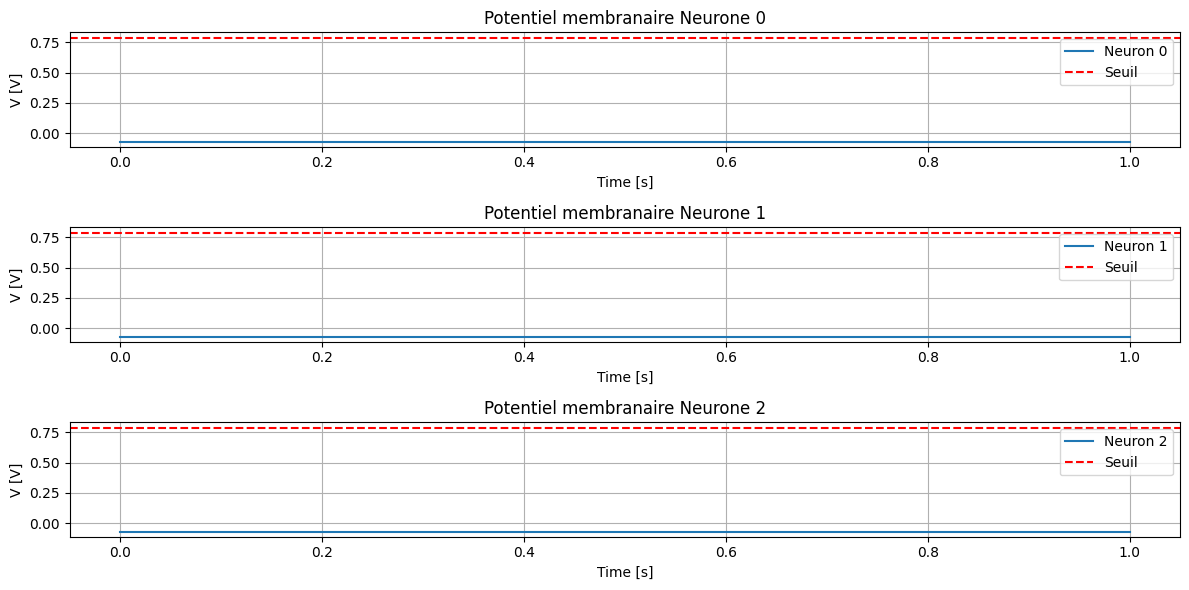

In [20]:
plt.figure(figsize=(12, 6))

for i, neuron in enumerate(output_spike_layer.neurons):
    plt.subplot(3, 1, i+1)
    plt.plot(np.arange(len(neuron.V_trace))*dt, neuron.V_trace, label=f'Neuron {i}')
    plt.xlabel('Time [s]')
    plt.ylabel('V [V]')
    plt.title(f'Potentiel membranaire Neurone {i}')
    plt.axhline(y=neuron.V_th, color='r', linestyle='--', label='Seuil')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()